In [1]:
import os
import gzip
import json
import pandas as pd

In [2]:
PATH = "./data/sports"

## Giải nén

In [3]:
dir_name_gz = "reviews_Sports_and_Outdoors_5.json.gz"
input_filepath_gz = os.path.join(PATH, dir_name_gz)

dir_name_json = dir_name_gz.replace(".json.gz", ".json")
output_filepath_json = os.path.join(PATH, dir_name_json)

with gzip.open(input_filepath_gz, 'rb') as f_in:
    with open(output_filepath_json, 'wb') as f_out:
        f_out.write(f_in.read())

print(f"Successfully unzipped {dir_name_gz} to {dir_name_json}")

Successfully unzipped reviews_Sports_and_Outdoors_5.json.gz to reviews_Sports_and_Outdoors_5.json


In [4]:
input_file = os.path.join(PATH, dir_name_json) # File nháy đơn
output_filepath_jsonl = os.path.join(PATH, dir_name_json.replace(".json", ".jsonl")) # File chuẩn

In [ ]:
# print("Đang chuẩn hóa dữ liệu...")

# with open(input_file, 'r', encoding='utf-8') as f_in, \
#      open(output_filepath_jsonl, 'w', encoding='utf-8') as f_out:
    
#     for line in f_in:
#         # 1. Dùng eval để đọc định dạng nháy đơn của Amazon
#         data_dict = eval(line)
        
#         # 2. Ghi lại bằng json.dumps để ép về chuẩn nháy kép
#         f_out.write(json.dumps(data_dict) + '\n')

# print(f"Hoàn thành! File chuẩn đã được lưu tại: {output_filepath_jsonl}")

In [5]:
import ast
import os

def fast_normalize(input_path, output_path, chunk_size=1000):
    print(f"Bắt đầu chuẩn hóa: {input_path}")
    
    with open(input_path, 'r', encoding='utf-8') as f_in, \
         open(output_path, 'w', encoding='utf-8') as f_out:
        
        buffer = []
        for line in f_in:
            line = line.strip()
            if not line: continue
            
            try:
                # ast.literal_eval nhanh và chuẩn hơn eval cho bài toán này
                data_dict = ast.literal_eval(line)
                buffer.append(json.dumps(data_dict) + '\n')
                
                # Khi đủ 1000 dòng thì ghi xuống ổ cứng 1 lần
                if len(buffer) >= chunk_size:
                    f_out.writelines(buffer)
                    buffer = []
            except:
                continue
        
        # Ghi nốt phần còn lại trong buffer
        if buffer:
            f_out.writelines(buffer)

    print(f"Hoàn thành! Đã lưu tại: {output_path}")
    print(f"Kích thước file mới: {os.path.getsize(output_path) / 1024 / 1024:.2f} MB")

In [6]:
# Chạy thử
# fast_normalize(input_file, output_filepath_jsonl)

Bắt đầu chuẩn hóa: ./data/sports\reviews_Sports_and_Outdoors_5.json
Hoàn thành! Đã lưu tại: ./data/sports\reviews_Sports_and_Outdoors_5.jsonl
Kích thước file mới: 198.72 MB


In [7]:
with open(output_filepath_jsonl, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i < 5:  # Print the first 5 lines
            print(line.strip())
        else:
            break

{"reviewerID": "AIXZKN4ACSKI", "asin": "1881509818", "reviewerName": "David Briner", "helpful": [0, 0], "reviewText": "This came in on time and I am veru happy with it, I haved used it already and it makes taking out the pins in my glock 32 very easy", "overall": 5.0, "summary": "Woks very good", "unixReviewTime": 1390694400, "reviewTime": "01 26, 2014"}
{"reviewerID": "A1L5P841VIO02V", "asin": "1881509818", "reviewerName": "Jason A. Kramer", "helpful": [1, 1], "reviewText": "I had a factory Glock tool that I was using for my Glock 26, 27, and 17.  I've since lost it and had needed another.  Since I've used Ghost products prior, and know that they are reliable, I had decided to order this one.  Sure enough, this is just as good as a factory tool.", "overall": 5.0, "summary": "Works as well as the factory tool", "unixReviewTime": 1328140800, "reviewTime": "02 2, 2012"}
{"reviewerID": "AB2W04NI4OEAD", "asin": "1881509818", "reviewerName": "J. Fernald", "helpful": [2, 2], "reviewText": "I

In [59]:
with open(output_filepath_jsonl, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        data = json.loads(line) # Đọc từng dòng
        print(f"Dòng {i+1}: Sản phẩm: {data.get('asin', 'N/A')}, Tiêu đề: {data.get('title', 'N/A')}, Hình ảnh: {data.get('imUrl', 'N/A')}")
        if i == 4: # Chỉ xem thử 5 dòng đầu
            break

Dòng 1: Sản phẩm: 0000032069, Tiêu đề: Adult Ballet Tutu Cheetah Pink, Hình ảnh: http://ecx.images-amazon.com/images/I/51EzU6quNML._SX342_.jpg
Dòng 2: Sản phẩm: 0000031909, Tiêu đề: Girls Ballet Tutu Neon Pink, Hình ảnh: http://ecx.images-amazon.com/images/I/41xBoP0FVzL._SY300_.jpg
Dòng 3: Sản phẩm: 0000032034, Tiêu đề: Adult Ballet Tutu Yellow, Hình ảnh: http://ecx.images-amazon.com/images/I/21GNUNIa1CL.jpg
Dòng 4: Sản phẩm: 0000031852, Tiêu đề: Girls Ballet Tutu Zebra Hot Pink, Hình ảnh: http://ecx.images-amazon.com/images/I/51fAmVkTbyL._SY300_.jpg
Dòng 5: Sản phẩm: 0000032050, Tiêu đề: Adult Ballet Tutu Purple, Hình ảnh: http://ecx.images-amazon.com/images/I/41TxNYG8cwL._SX342_.jpg


In [ ]:
# dành cho file lớn, ở đây file nhỏ nên đọc trực tiếp
# chunks = pd.read_json(os.path.join(PATH, "reviews_Sports_and_Outdoors_5.jsonl"), lines=True, chunksize=100_000)
# df = next(chunks)
# chunks.close()

In [60]:
df = pd.read_json(output_filepath_jsonl, lines=True)

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 532197 entries, 0 to 532196
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   asin         532197 non-null  str    
 1   title        529901 non-null  str    
 2   price        287792 non-null  float64
 3   imUrl        531613 non-null  str    
 4   related      388118 non-null  object 
 5   brand        152487 non-null  str    
 6   categories   532197 non-null  object 
 7   salesRank    486349 non-null  object 
 8   description  402371 non-null  str    
dtypes: float64(1), object(3), str(5)
memory usage: 36.5+ MB


In [63]:
df.head(3)

,asin,title,price,imUrl,related,brand,categories,salesRank,description
0,0000032069,Adult Ballet Tutu Cheetah Pink,7.89,http://ecx.images-amazon.com/images/I/51EzU6qu...,"{'also_bought': ['0000032050', 'B00D0DJAEG', '...",BubuBibi,"[[Sports & Outdoors, Other Sports, Dance, Clot...",NaN,NaN
1,0000031909,Girls Ballet Tutu Neon Pink,7.00,http://ecx.images-amazon.com/images/I/41xBoP0F...,"{'also_bought': ['B002BZX8Z6', 'B00JHONN1S', '...",Unknown,"[[Sports & Outdoors, Other Sports, Dance]]",{'Toys & Games': 201847},High quality 3 layer ballet tutu. 12 inches in...
2,0000032034,Adult Ballet Tutu Yellow,7.87,http://ecx.images-amazon.com/images/I/21GNUNIa...,"{'also_bought': ['B00D2JSRFQ', '0000032042', '...",BubuBibi,"[[Sports & Outdoors, Other Sports, Dance, Clot...",NaN,NaN


## Load df

In [4]:
df_meta = pd.read_json(os.path.join(PATH, "meta_Sports_and_Outdoors.jsonl"), lines=True)

In [5]:
df_meta.info()

<class 'pandas.DataFrame'>
RangeIndex: 532197 entries, 0 to 532196
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   asin         532197 non-null  str    
 1   title        529901 non-null  str    
 2   price        287792 non-null  float64
 3   imUrl        531613 non-null  str    
 4   related      388118 non-null  object 
 5   brand        152487 non-null  str    
 6   categories   532197 non-null  object 
 7   salesRank    486349 non-null  object 
 8   description  402371 non-null  str    
dtypes: float64(1), object(3), str(5)
memory usage: 269.6+ MB


In [6]:
# Loại bỏ các sản phẩm không có hình ảnh (vì SMORE là đa phương thức)
df_meta_clean = df_meta.dropna(subset=['imUrl']).copy()

In [7]:
df_meta.info()

<class 'pandas.DataFrame'>
RangeIndex: 532197 entries, 0 to 532196
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   asin         532197 non-null  str    
 1   title        529901 non-null  str    
 2   price        287792 non-null  float64
 3   imUrl        531613 non-null  str    
 4   related      388118 non-null  object 
 5   brand        152487 non-null  str    
 6   categories   532197 non-null  object 
 7   salesRank    486349 non-null  object 
 8   description  402371 non-null  str    
dtypes: float64(1), object(3), str(5)
memory usage: 269.6+ MB


In [8]:
df_meta.head(3)

,asin,title,price,imUrl,related,brand,categories,salesRank,description
0,0000032069,Adult Ballet Tutu Cheetah Pink,7.89,http://ecx.images-amazon.com/images/I/51EzU6qu...,"{'also_bought': ['0000032050', 'B00D0DJAEG', '...",BubuBibi,"[[Sports & Outdoors, Other Sports, Dance, Clot...",NaN,NaN
1,0000031909,Girls Ballet Tutu Neon Pink,7.00,http://ecx.images-amazon.com/images/I/41xBoP0F...,"{'also_bought': ['B002BZX8Z6', 'B00JHONN1S', '...",Unknown,"[[Sports & Outdoors, Other Sports, Dance]]",{'Toys & Games': 201847},High quality 3 layer ballet tutu. 12 inches in...
2,0000032034,Adult Ballet Tutu Yellow,7.87,http://ecx.images-amazon.com/images/I/21GNUNIa...,"{'also_bought': ['B00D2JSRFQ', '0000032042', '...",BubuBibi,"[[Sports & Outdoors, Other Sports, Dance, Clot...",NaN,NaN


In [9]:
df_reviews = pd.read_json(os.path.join(PATH, "reviews_Sports_and_Outdoors_5.jsonl"), lines=True)

In [10]:
df_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 296337 entries, 0 to 296336
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   reviewerID      296337 non-null  str   
 1   asin            296337 non-null  str   
 2   reviewerName    294935 non-null  str   
 3   helpful         296337 non-null  object
 4   reviewText      296337 non-null  str   
 5   overall         296337 non-null  int64 
 6   summary         296337 non-null  str   
 7   unixReviewTime  296337 non-null  int64 
 8   reviewTime      296337 non-null  str   
dtypes: int64(2), object(1), str(6)
memory usage: 171.5+ MB


In [11]:
df_reviews.head(3)

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,AIXZKN4ACSKI,1881509818,David Briner,"[0, 0]",This came in on time and I am veru happy with ...,5,Woks very good,1390694400,"01 26, 2014"
1,A1L5P841VIO02V,1881509818,Jason A. Kramer,"[1, 1]",I had a factory Glock tool that I was using fo...,5,Works as well as the factory tool,1328140800,"02 2, 2012"
2,AB2W04NI4OEAD,1881509818,J. Fernald,"[2, 2]",If you don't have a 3/32 punch or would like t...,4,"It's a punch, that's all.",1330387200,"02 28, 2012"


In [12]:
# Lọc ra meta của sản phẩm có trong reviews 5 core
asins_in_reviews = set(df_reviews['asin'].unique())
df_meta_filtered = df_meta[df_meta['asin'].isin(asins_in_reviews)].copy()

In [13]:
df_meta_filtered.info()

<class 'pandas.DataFrame'>
Index: 18357 entries, 132 to 532165
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   asin         18357 non-null  str    
 1   title        18267 non-null  str    
 2   price        14764 non-null  float64
 3   imUrl        18325 non-null  str    
 4   related      18236 non-null  object 
 5   brand        12333 non-null  str    
 6   categories   18357 non-null  object 
 7   salesRank    16055 non-null  object 
 8   description  16620 non-null  str    
dtypes: float64(1), object(3), str(5)
memory usage: 13.0+ MB


In [14]:
print(df_meta_filtered.shape)
print(df_reviews.shape)

(18357, 9)
(296337, 9)


In [15]:
df_meta_with_reviews = df_meta_filtered.merge(df_reviews, on='asin', how='inner')

In [16]:
df_meta_with_reviews.shape

(296337, 17)

In [17]:
%pip install pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# df_meta_with_reviews.to_json(os.path.join(PATH, "meta_reviews_merged.jsonl"), orient='records', lines=True)
# write to parquet for faster loading in the future
df_meta_with_reviews.to_parquet(
    os.path.join(PATH, "meta_reviews_merged.gzip.parquet"), 
    engine='pyarrow', 
    compression='gzip', 
    index=False
)

In [32]:
df_ratings = pd.read_csv(r"data\sports\ratings_Sports_and_Outdoors.csv", names=['userID', 'itemID', 'rating', 'timestamp'], header=None)

In [34]:
df_ratings.shape

(3268695, 4)

In [38]:
df_ratings.head(3)

,userID,itemID,rating,timestamp
0,A3PMSRCL80KSA1,0000031852,4.0,1388275200
1,A1SNLWGLFXD70K,0000031852,4.0,1392940800
2,A1KJ4CVG87QW09,0000031852,4.0,1389657600


In [35]:
df_reviews.shape

(296337, 9)

In [40]:
asins_in_ratings = set(df_ratings['itemID'].unique())
df_meta_ratings_filtered = df_meta_filtered[df_meta_filtered['asin'].isin(asins_in_ratings)].copy()

In [41]:
df_meta_ratings_filtered.info()

<class 'pandas.DataFrame'>
Index: 18357 entries, 132 to 532165
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   asin         18357 non-null  str    
 1   title        18267 non-null  str    
 2   price        14764 non-null  float64
 3   imUrl        18325 non-null  str    
 4   related      18236 non-null  object 
 5   brand        12333 non-null  str    
 6   categories   18357 non-null  object 
 7   salesRank    16055 non-null  object 
 8   description  16620 non-null  str    
dtypes: float64(1), object(3), str(5)
memory usage: 13.0+ MB


In [42]:
df_meta_ratings_filtered.shape

(18357, 9)

In [43]:
df_meta_filtered.shape

(18357, 9)

In [ ]:
# 2 vậy ratings và reviews 5 core khác size vì tiêu chỉ lọc khác nhau
# nhưng số sản phẩm liên quan vẫn y hệt
df_meta_ratings_filtered.compare(df_meta_filtered)

Empty DataFrame
Columns: []
Index: []

In [3]:
df_meta_filtered = pd.read_parquet(os.path.join(PATH, "meta_filtered.gzip.parquet"))

In [4]:
df_meta_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 18357 entries, 0 to 18356
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   asin         18357 non-null  str    
 1   title        18267 non-null  str    
 2   price        14764 non-null  float64
 3   imUrl        18325 non-null  str    
 4   related      18236 non-null  object 
 5   brand        12333 non-null  str    
 6   categories   18357 non-null  object 
 7   salesRank    16055 non-null  object 
 8   description  16620 non-null  str    
dtypes: float64(1), object(3), str(5)
memory usage: 12.8+ MB


In [ ]:
# import array

# # https://cseweb.ucsd.edu/~jmcauley/datasets/amazon/links.html
# def readImageFeatures(path):
#   f = open(path, 'rb')
#   while True:
#     asin = f.read(10).decode('UTF-8')
#     if asin == '': break
#     a = array.array('f')
#     a.fromfile(f, 4096)
#     yield asin, a.tolist()

In [8]:
import numpy as np
import os

def extract_and_filter_features(path_b, valid_asin_set):
    """
    Đọc file .b, lọc các ASIN có trong valid_asin_set và trả về ma trận numpy.
    
    Args:
        path_b (str): Đường dẫn đến file image_features_Sports_and_Outdoors.b
        valid_asin_set (set): Tập hợp (set) các ASIN cần giữ lại (lấy từ df_meta_filtered['asin'])
        
    Returns:
        tuple: (Ma trận đặc trưng numpy float32, Danh sách ASIN tương ứng)
    """
    filtered_asins = []
    filtered_features = []
    
    # Kích thước phần vector: 4096 số float32 * 4 bytes = 16384 bytes
    feat_size_bytes = 4096 * 4 
    
    print(f"Bắt đầu trích xuất từ: {path_b}...")
    
    with open(path_b, 'rb') as f:
        while True:
            # 1. Đọc 10 bytes đầu tiên chứa ASIN
            asin_bytes = f.read(10)
            if not asin_bytes:
                break # Hết file
                
            asin = asin_bytes.decode('utf-8').strip()
            
            # 2. Kiểm tra nhanh trong SET (tốc độ O(1))
            if asin in valid_asin_set:
                # Nếu khớp, nạp vector vào RAM
                feat = np.fromfile(f, dtype='float32', count=4096)
                filtered_asins.append(asin)
                filtered_features.append(feat)
            else:
                # Nếu không khớp, nhảy qua vùng dữ liệu này (không tốn RAM để nạp)
                f.seek(feat_size_bytes, 1)
                
    # Chuyển list các vector thành ma trận 2D
    feature_matrix = np.array(filtered_features, dtype='float32')
    
    print(f"Xong! Giữ lại được {len(filtered_asins)} / {len(valid_asin_set)} sản phẩm.")
    return feature_matrix, filtered_asins

In [9]:
# --- CÁCH SỬ DỤNG ---
# 1. Tạo set ASIN để lookup nhanh
target_asins = set(df_meta_filtered['asin'].unique())

# 2. Chạy hàm
path_bin = os.path.join(PATH, "image_features_Sports_and_Outdoors.b")
image_matrix, image_asin_list = extract_and_filter_features(path_bin, target_asins)

# 3. Lưu lại để dùng cho huấn luyện
np.save(os.path.join(PATH, 'image_feat_final.npy'), image_matrix)

Bắt đầu trích xuất từ: ./data/sports\image_features_Sports_and_Outdoors.b...
Xong! Giữ lại được 18177 / 18357 sản phẩm.


In [14]:
# 2. Tạo một DataFrame mapping từ kết quả trả về
df_image_map = pd.DataFrame({
    'asin': image_asin_list,
    'image_index': range(len(image_asin_list))
})

In [34]:
# 1. Tạo một DataFrame tạm để giữ đúng thứ tự của Ảnh
df_image_order = pd.DataFrame({
    'asin': image_asin_list,
    'image_row_index': range(len(image_asin_list))
})

# 2. Merge với Metadata của bạn
# Phải dùng 'inner' join để loại bỏ những cái không có ảnh hoặc không có metadata
df_meta_with_image = pd.merge(df_image_order, df_meta_filtered, on='asin', how='inner')

# 3. Sắp xếp lại df_meta_final theo đúng thứ tự image_row_index
df_meta_with_image = df_meta_with_image.sort_values('image_row_index').reset_index(drop=True)

In [37]:
image_asin_list[:3]

['B000FON3KU', 'B000BSWEF0', 'B000ENOPO0']

In [38]:
df_meta_with_image.head(3)

,asin,image_row_index,title,price,imUrl,related,brand,categories,salesRank,description
0,B000FON3KU,0,Bionic Men's Fitness Gloves,NaN,http://ecx.images-amazon.com/images/I/4176MJfl...,"{'also_bought': ['B001ZTU4SS', 'B00H1KKLI8', '...",NaN,"[[Sports & Outdoors, Clothing, Men, Accessorie...","{'Arts, Crafts & Sewing': None, 'Automotive': ...",The men's fitness gloves from Bionic are desig...
1,B000BSWEF0,1,Spyderco C88PBK Salt I Lockback Knife,67.78,http://ecx.images-amazon.com/images/I/210Y76MV...,"{'also_bought': ['B004HIZKHE', 'B0018RMB8I', '...",Spyderco,"[[Sports & Outdoors, Hunting & Fishing, Huntin...","{'Arts, Crafts & Sewing': None, 'Automotive': ...",The Salt I has a more rounded tip that's a bit...
2,B000ENOPO0,2,Slime Tube Sealant,NaN,http://ecx.images-amazon.com/images/I/41GNiVJa...,"{'also_bought': ['B0020T17J2', 'B007OX6E3S', '...",NaN,"[[Sports & Outdoors, Cycling, Tires & Tubes, T...",None,Permanently seals tube punctures up to 1/8 inc...


In [11]:
df_meta_with_image["title"]

0                              Bionic Men's Fitness Gloves
1                    Spyderco C88PBK Salt I Lockback Knife
2                                       Slime Tube Sealant
3        DuPont Teflon Multi-Use Lubricant Aerosol Spra...
4                                            MSR Titan Cup
                               ...                        
18172     VZ Grips Operator II Standard Full Size Gun Grip
18173                   Igloo Stainless Steel Cooler Latch
18174    Ultimate Arms Gear Tactical Stealth Black M16 ...
18175                         Cressi Supernova Dry Snorkel
18176           UTG Swivel Stud Picatinny Slot Adaptor Kit
Name: title, Length: 18177, dtype: str

In [40]:
df_meta_with_image.to_parquet(os.path.join(PATH, "meta_with_image.gzip.parquet"), engine='pyarrow', compression='gzip', index=False)

In [41]:
image_matrix[0]

array([0.    , 0.    , 1.4426, ..., 0.    , 0.    , 0.    ],
      shape=(4096,), dtype=float32)

In [17]:
# target_asins


In [18]:
df_meta_filtered["asin"][:3]

0    1881509818
1    2094869245
2    7245456313
Name: asin, dtype: str

In [19]:
image_asin_list[:3]

['B000FON3KU', 'B000BSWEF0', 'B000ENOPO0']

In [22]:
df_meta_filtered[df_meta_filtered["asin"] == "B000FON3KU"]["asin"]

2343    B000FON3KU
Name: asin, dtype: str

## Data exploration

In [3]:
df_meta_with_image = pd.read_parquet(os.path.join(PATH, "meta_with_image.gzip.parquet"))

In [4]:
df_meta_with_image["title"].value_counts()

title
MASSIVE SALE&quot; Knife King Custom Damascus Handmade Hunting Knife. With Leather Sheath. Top Quality                                        5
Camelbak Eddy Bottle 0.75-Liter/24-Ounce                                                                                                      5
Speedo Men's Race Endurance+ Polyester Solid Jammer Swimsuit                                                                                  3
Eagles Nest Outfitters Guardian Bug Net                                                                                                       3
UTG Airgun .22 High Profile Integral 1-Inch Ring Mount                                                                                        3
                                                                                                                                             ..
VZ Grips Operator II Standard Full Size Gun Grip                                                                                  

In [7]:
df_meta_with_image[df_meta_with_image["description"] == ""]["description"]

25        
38        
87        
91        
113       
        ..
18088     
18115     
18148     
18158     
18168     
Name: description, Length: 906, dtype: str

In [10]:
# Biểu thức Regex để tìm các thẻ dạng <...>
html_pattern = r'<[^>]+>'

# Tìm các dòng có chứa thẻ HTML
rows_with_html = df_meta_with_image[df_meta_with_image['description'].str.contains(html_pattern, na=False, regex=True)]

# Hiển thị số lượng dòng tìm thấy
print(f"Số lượng dòng chứa thẻ HTML: {len(rows_with_html)}")

# Xem thử 5 dòng đầu tiên
print(rows_with_html['description'].head())

Số lượng dòng chứa thẻ HTML: 18
424     [if gte mso 9]><xml> <w:WordDocument> <w:View>...
1193    [if gte mso 9]><xml> <w:WordDocument> <w:View>...
2862    Zoot Race-Day Belt :: The Zoot Race Day Belt i...
3333    Pearl Izumi Thermal Skull Cap :: P.R.O. Therma...
4287    [if gte mso 9]><xml> <o:OfficeDocumentSettings...
Name: description, dtype: str


In [24]:
%pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
# Chọn 1 dòng dữ liệu, dùng ngoặc vuông kép [[]] để giữ định dạng DataFrame
sample_data = rows_with_html.iloc[[0]][["asin", "title", "imUrl", "description"]]

# Xoay khổ dọc: Cột thành Dòng
sample_data_vertical = sample_data.T

# Ghi ra Excel (Lần này phải để index=True để nó hiện tên asin, title, description ở cột A)
sample_data_vertical.to_excel("sample_html_issue_vertical.xlsx", header=False)

In [28]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


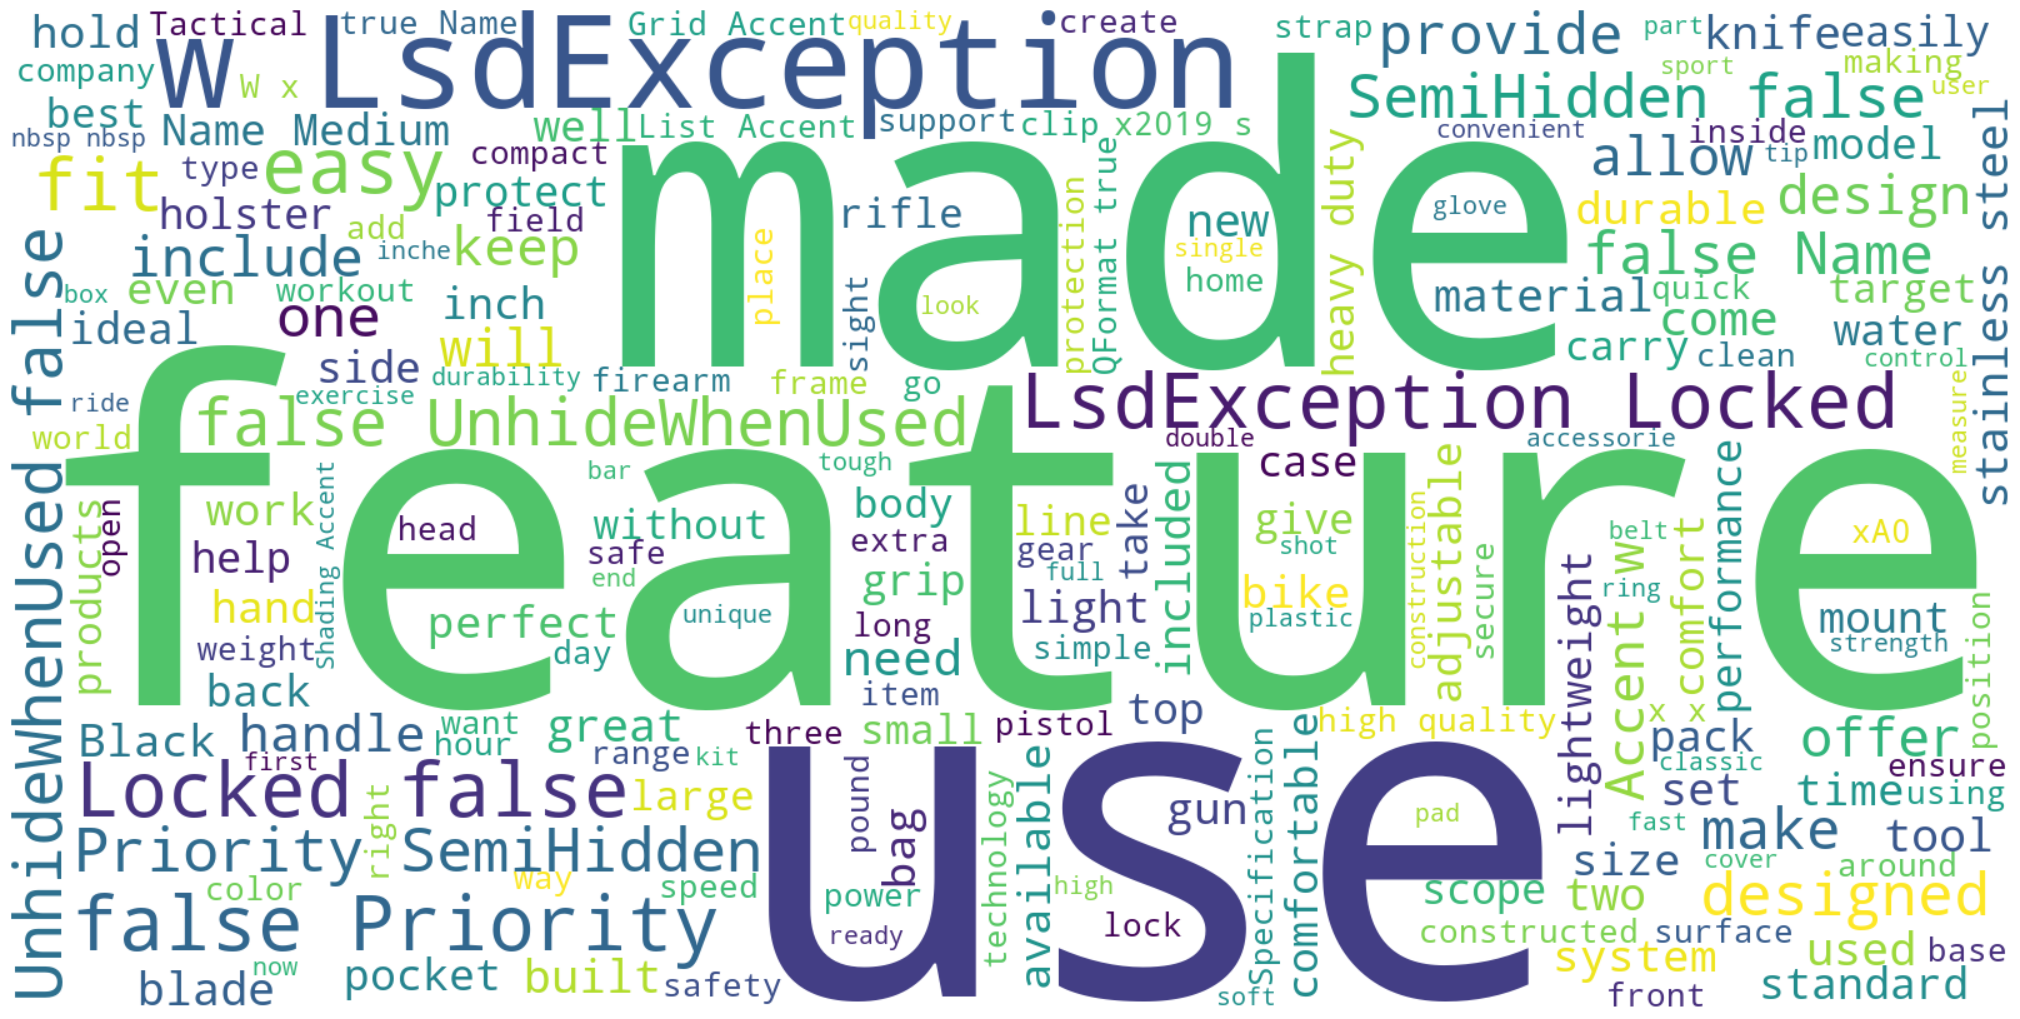

In [31]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# 1. Chuẩn bị dữ liệu: Gộp tất cả title thành một đoạn văn bản lớn
# Bỏ các giá trị rỗng (NaN)
text = " ".join(title for title in df_meta_with_image['description'].dropna())

# 2. Loại bỏ các từ vô nghĩa (Stopwords)
# Bạn có thể thêm các từ nhiễu vào đây nếu thấy nó hiện quá to trên hình
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(["Amazon", "Product", "Brand", "Shipping"]) 

# 3. Khởi tạo WordCloud
wordcloud = WordCloud(
    width=1600, 
    height=800, 
    background_color='white', # Màu nền trắng cho dễ chèn vào báo cáo
    stopwords=custom_stopwords,
    min_font_size=10,
    colormap='viridis' # Bộ màu nhìn hiện đại
).generate(text)

# 4. Hiển thị và lưu hình
plt.figure(figsize=(20, 10), facecolor=None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") # Tắt trục tọa độ
plt.tight_layout(pad=0)

# Lưu lại file chất lượng cao để in báo cáo
plt.savefig("title_wordcloud.png", dpi=300)
plt.show()

In [1]:
import torch
print(torch.__version__)

2.10.0+cpu


In [4]:
%pip install networkx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


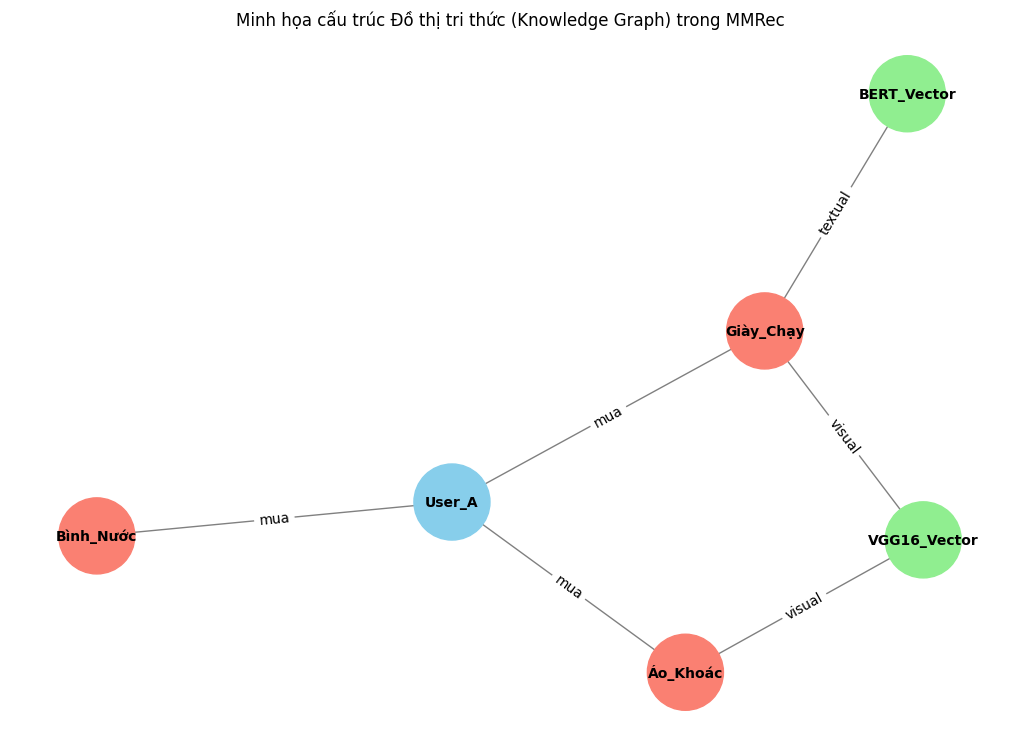

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Khởi tạo đồ thị
G = nx.Graph()

# 2. Thêm các Nút (Nodes) và phân loại nhóm để tô màu
user_node = "User_A"
items = ["Giày_Chạy", "Áo_Khoác", "Bình_Nước"]
features = ["VGG16_Vector", "BERT_Vector"]

G.add_node(user_node, type='user')
G.add_nodes_from(items, type='item')
G.add_nodes_from(features, type='feature')

# 3. Thêm các Cạnh (Edges) - Thiết lập mối quan hệ
# User mua sản phẩm
for item in items:
    G.add_edge(user_node, item, label='mua')

# Sản phẩm có đặc trưng đa phương thức
G.add_edge("Giày_Chạy", "VGG16_Vector", label='visual')
G.add_edge("Giày_Chạy", "BERT_Vector", label='textual')
G.add_edge("Áo_Khoác", "VGG16_Vector", label='visual')

# 4. Thiết lập vị trí và màu sắc để vẽ cho đẹp
pos = nx.spring_layout(G, seed=42) # Sắp xếp nút tự động

# Tô màu: User (Xanh dương), Item (Đỏ), Feature (Xanh lá)
color_map = []
for node in G:
    if G.nodes[node]['type'] == 'user':
        color_map.append('skyblue')
    elif G.nodes[node]['type'] == 'item':
        color_map.append('salmon')
    else:
        color_map.append('lightgreen')

# 5. Vẽ đồ thị
plt.figure(figsize=(10, 7))
nx.draw(G, pos, with_labels=True, node_color=color_map, 
        node_size=3000, font_size=10, font_weight='bold', edge_color='gray')

# Vẽ nhãn cho các cạnh (mua, visual, textual)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Minh họa cấu trúc Đồ thị tri thức (Knowledge Graph) trong MMRec")
plt.show()

In [34]:
df_ratings.head(3)

,userID,itemID,rating,timestamp
0,A3PMSRCL80KSA1,0000031852,4.0,1388275200
1,A1SNLWGLFXD70K,0000031852,4.0,1392940800
2,A1KJ4CVG87QW09,0000031852,4.0,1389657600


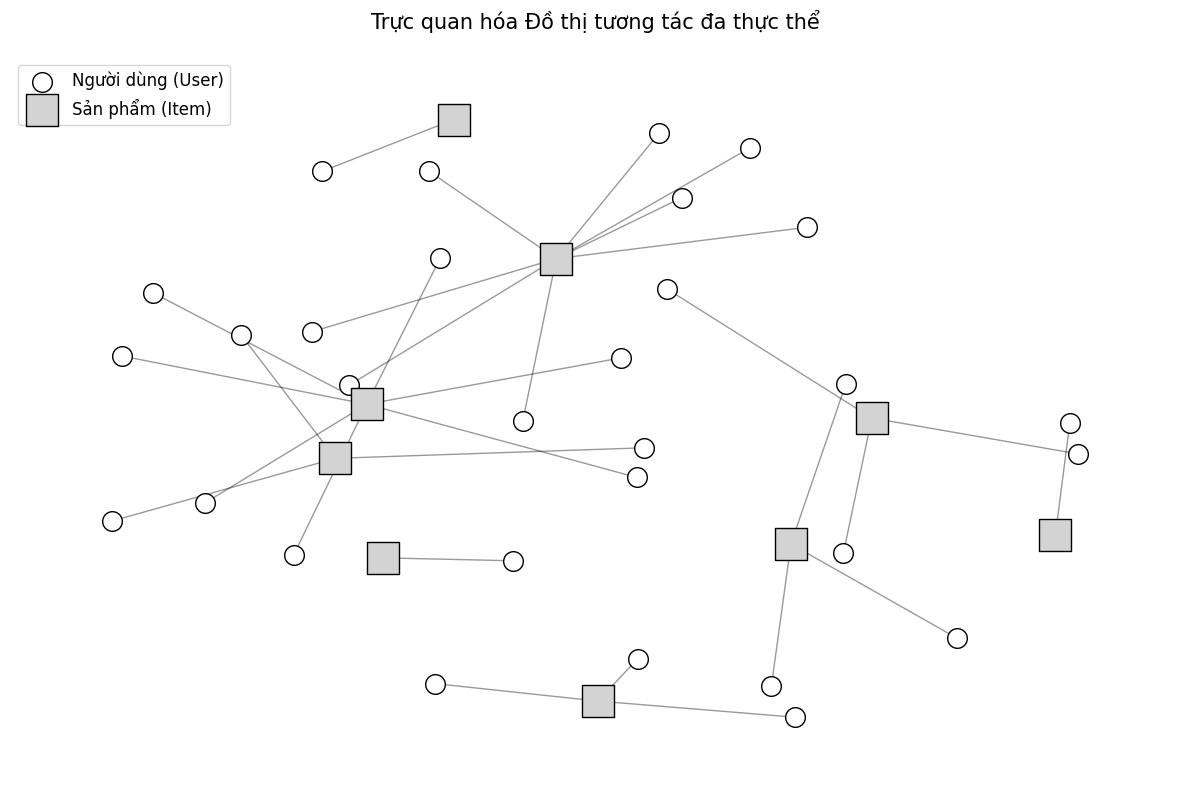

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. Lấy mẫu dữ liệu (Bạn nên lấy ít để hình không bị rối)
df_plot = df_ratings.head(30)

# 2. Khởi tạo đồ thị
G = nx.Graph()
for _, row in df_plot.iterrows():
    G.add_edge(row['userID'], row['itemID'])

# 3. Phân loại danh sách Node
user_nodes = [n for n in G.nodes if n in df_plot['userID'].unique()]
item_nodes = [n for n in G.nodes if n in df_plot['itemID'].unique()]

# 4. Thiết lập vị trí (Layout)
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.6, seed=42)

# 5. Vẽ từng nhóm Node với hình dáng và kích thước khác nhau
# Vẽ Người dùng (User): Hình tròn (o), kích thước nhỏ
nx.draw_networkx_nodes(G, pos, nodelist=user_nodes, 
                       node_shape='o', 
                       node_size=200, 
                       node_color='white', 
                       edgecolors='black', 
                       label='Người dùng (User)')

# Vẽ Sản phẩm (Item): Hình vuông (s), kích thước lớn hơn
nx.draw_networkx_nodes(G, pos, nodelist=item_nodes, 
                       node_shape='s', 
                       node_size=500, 
                       node_color='lightgray', 
                       edgecolors='black', 
                       label='Sản phẩm (Item)')

# 6. Vẽ cạnh (Edges)
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.4, edge_color='black')

# 7. Thêm chú thích (Legend)
plt.legend(scatterpoints=1, loc='upper left', fontsize=12)

plt.title("Trực quan hóa Đồ thị tương tác đa thực thể", fontsize=15, pad=20)
plt.axis('off') # Tắt khung trục
plt.tight_layout()
plt.show()

In [62]:
df_meta_with_reviews = pd.read_parquet(os.path.join(PATH, "meta_reviews_merged.gzip.parquet"), engine='pyarrow')

In [65]:
df_meta_with_reviews[["reviewerID", "reviewerName"]]

,reviewerID,reviewerName
0,AIXZKN4ACSKI,David Briner
1,A1L5P841VIO02V,Jason A. Kramer
2,AB2W04NI4OEAD,J. Fernald
3,A148SVSWKTJKU6,"Jusitn A. Watts ""Maverick9614"""
4,AAAWJ6LW9WMOO,Material Man
...,...,...
296332,A2XX2A4OJCDNLZ,RatherLiveInKeyWest
296333,A3LGT6UZL99IW1,"Richard C. Drew ""Anaal Nathra/Uthe vas Bethod..."
296334,ASKZO80Z1RKTR,Robin Lee
296335,APRNS6DB68LLV,"Rob Slaven ""slavenrm@gmail. com"""


In [63]:
df_meta_with_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 296337 entries, 0 to 296336
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   asin            296337 non-null  str    
 1   title           295091 non-null  str    
 2   price           246116 non-null  float64
 3   imUrl           295896 non-null  str    
 4   related         294878 non-null  object 
 5   brand           217411 non-null  str    
 6   categories      296337 non-null  object 
 7   salesRank       256125 non-null  object 
 8   description     273341 non-null  str    
 9   reviewerID      296337 non-null  str    
 10  reviewerName    294935 non-null  str    
 11  helpful         296337 non-null  object 
 12  reviewText      296337 non-null  str    
 13  overall         296337 non-null  int64  
 14  summary         296337 non-null  str    
 15  unixReviewTime  296337 non-null  int64  
 16  reviewTime      296337 non-null  str    
dtypes: float64(1), int64(

In [53]:
df_ratings[df_ratings['itemID'] == 'B000FON3KU']

,userID,itemID,rating,timestamp
414352,AYUU3IQP92WZ2,B000FON3KU,5.0,1399507200
414353,A27CWPLW9XWQI1,B000FON3KU,1.0,1375920000
414354,A39QQ9F7BJ0QJY,B000FON3KU,3.0,1347667200
414355,A3L90WC8PJBUXM,B000FON3KU,5.0,1356739200
414356,A1DV5O62IDKGZA,B000FON3KU,5.0,1364860800
...,...,...,...,...
414423,A2SP8SF3TKX56G,B000FON3KU,5.0,1238889600
414424,AR6H0CKX2U615,B000FON3KU,4.0,1367107200
414425,A22I55P15NSAOX,B000FON3KU,4.0,1321920000
414426,A3A38K4XTL3JUW,B000FON3KU,5.0,1322438400


In [55]:
df_meta_with_image[df_meta_with_image["asin"] == "B000FON3KU"]

,asin,image_row_index,title,price,imUrl,related,brand,categories,salesRank,description
0,B000FON3KU,0,Bionic Men's Fitness Gloves,NaN,http://ecx.images-amazon.com/images/I/4176MJfl9SL._SY300...,"{'also_bought': ['B001ZTU4SS', 'B00H1KKLI8', 'B001ZTP0CI...",NaN,"[[Sports & Outdoors, Clothing, Men, Accessories, Gloves,...","{'Arts, Crafts & Sewing': None, 'Automotive': None, 'Bea...",The men's fitness gloves from Bionic are designed by an ...


In [86]:
df_ratings

,userID,itemID,rating,timestamp
0,A3PMSRCL80KSA1,0000031852,4.0,1388275200
1,A1SNLWGLFXD70K,0000031852,4.0,1392940800
2,A1KJ4CVG87QW09,0000031852,4.0,1389657600
3,AA9ITO6ZLZW6,0000031852,5.0,1399507200
4,APJ5ULJ1RMZ4,0000031852,1.0,1398556800
...,...,...,...,...
3268690,A1XNL3C5RL8AC,B00LVHLRZ8,5.0,1405382400
3268691,A1BV7953RLM07E,B00LVHLRZ8,5.0,1405382400
3268692,A1ZUS94QF43DAC,B00LVHLRZ8,5.0,1405641600
3268693,A32T585IZ0DJX2,B00LVHLRZ8,5.0,1405900800


In [93]:
import pandas as pd

target_asin = "B000FON3KU"

# 1. Lấy thông tin sản phẩm (Bảng này chắc chắn có 'asin' và 'title')
df_target_item = df_meta_with_image[df_meta_with_image['asin'] == target_asin][['asin', 'title']]

# 2. Xử lý bảng Ratings (Tự động thích nghi với itemID hoặc asin)
col_item = 'itemID' if 'itemID' in df_ratings.columns else 'asin'
col_user = 'userID' if 'userID' in df_ratings.columns else 'reviewerID'

# Lọc dữ liệu rating
df_target_ratings = df_ratings[df_ratings[col_item] == target_asin].copy()

# 3. Lấy thông tin người dùng (Bảng này thường dùng reviewerID/reviewerName)
df_users = df_meta_with_reviews[['reviewerID', 'reviewerName']].drop_duplicates()

# 4. TIẾN HÀNH GHÉP BẢNG
# Ghép Ratings với Metadata
df_step1 = pd.merge(df_target_ratings, df_target_item, left_on=col_item, right_on='asin', how='inner')

# Ghép với thông tin tên người dùng
df_product_final_plot = pd.merge(df_step1, df_users, left_on=col_user, right_on='reviewerID', how='inner')

# 5. LÀM SẠCH VÀ CHUẨN BỊ VẼ
df_product_final_plot['reviewerName'] = df_product_final_plot['reviewerName'].fillna("User " + df_product_final_plot[col_user].str[:5])
df_product_final_plot = df_product_final_plot.head(5)

# Kiểm tra kết quả
print("Dữ liệu đã sẵn sàng để vẽ đồ thị:")
display(df_product_final_plot[['reviewerName', 'title', 'rating']])

Dữ liệu đã sẵn sàng để vẽ đồ thị:


,reviewerName,title,rating
0,"Amazon Customer ""Math puzzler""",Bionic Men's Fitness Gloves,4.0
1,"bionichands ""procrastinator""",Bionic Men's Fitness Gloves,3.0
2,Bunson Honeydew,Bionic Men's Fitness Gloves,5.0
3,"Emily J. Morris ""Backroads""",Bionic Men's Fitness Gloves,4.0
4,"esanta ""esanta""",Bionic Men's Fitness Gloves,5.0


In [69]:
asin = "B000FON3KU"

In [83]:
df_ratings[df_ratings['itemID'] == asin].head(3)

,userID,itemID,rating,timestamp
414352,AYUU3IQP92WZ2,B000FON3KU,5.0,1399507200
414353,A27CWPLW9XWQI1,B000FON3KU,1.0,1375920000
414354,A39QQ9F7BJ0QJY,B000FON3KU,3.0,1347667200


In [71]:
df_meta_with_image[df_meta_with_image["asin"] == asin]

,asin,image_row_index,title,price,imUrl,related,brand,categories,salesRank,description
0,B000FON3KU,0,Bionic Men's Fitness Gloves,NaN,http://ecx.images-amazon.com/images/I/4176MJfl9SL._SY300...,"{'also_bought': ['B001ZTU4SS', 'B00H1KKLI8', 'B001ZTP0CI...",NaN,"[[Sports & Outdoors, Clothing, Men, Accessories, Gloves,...","{'Arts, Crafts & Sewing': None, 'Automotive': None, 'Bea...",The men's fitness gloves from Bionic are designed by an ...


In [82]:
df_meta_with_reviews[(df_meta_with_reviews["asin"] == asin) & (df_meta_with_reviews["reviewerID"] == "A250AXLRBVYKB4")][["reviewerID", "reviewerName", "reviewText"]]

,reviewerID,reviewerName,reviewText
41778,A250AXLRBVYKB4,"Nathan Beauchamp ""ConsumerAdvocate (nathan(at...",I've used various workout gloves in my lifetime because ...


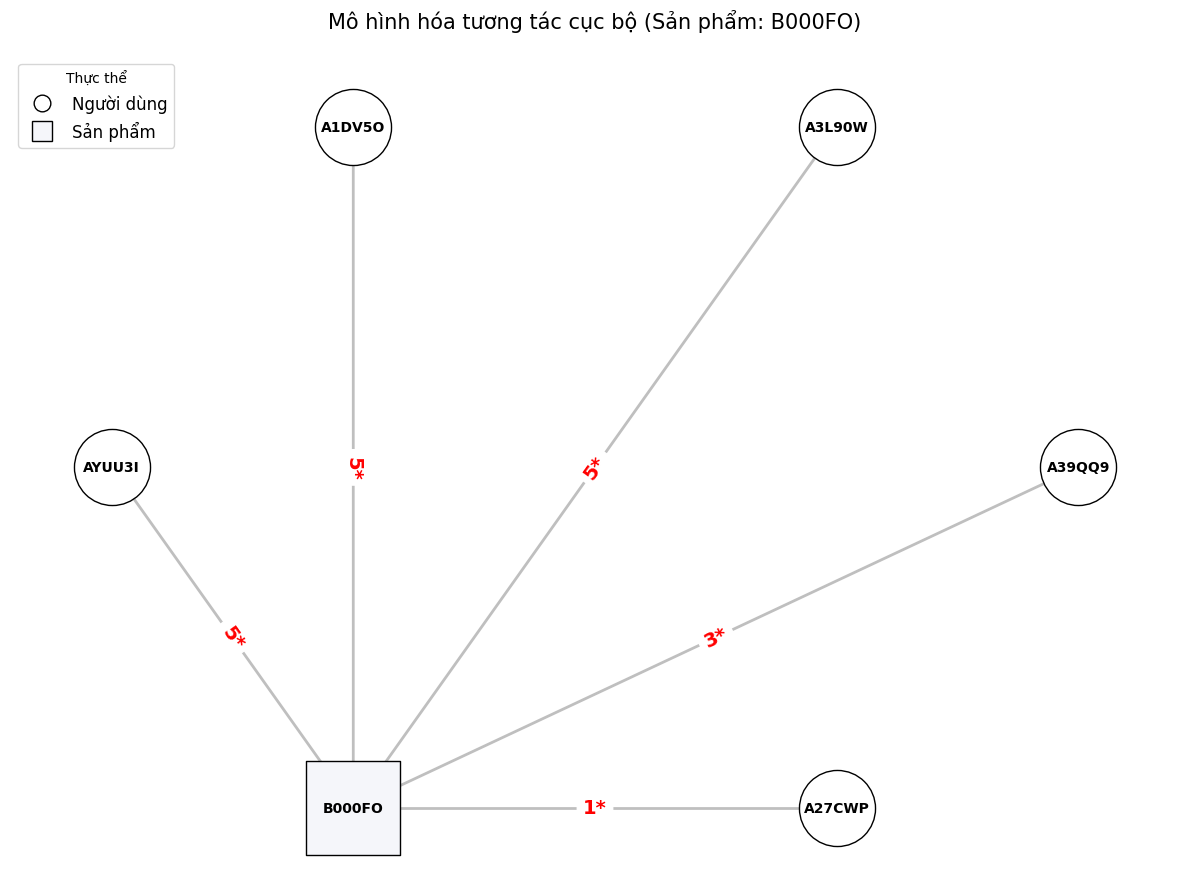

In [90]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# 1. Chuẩn bị dữ liệu (Giữ nguyên logic cũ)
target_item = df_ratings['itemID'].iloc[0]
df_sub = df_ratings[df_ratings['itemID'] == "B000FON3KU"].head(5)

# 2. Khởi tạo đồ thị
G = nx.Graph()
for _, row in df_sub.iterrows():
    u_id = row['userID'][:6] # Rút gọn ID
    i_id = row['itemID'][:6]
    rating_label = f"{int(row['rating'])}*"
    G.add_edge(u_id, i_id, label=rating_label)

user_nodes = [n for n in G.nodes if n != i_id]
item_node = [i_id]

# 3. Vẽ đồ thị
plt.figure(figsize=(12, 9))
# Sử dụng layout vòng tròn (shell) để các node vệ tinh bao quanh node trung tâm
pos = nx.shell_layout(G) 

# --- VẼ CÁC THÀNH PHẦN (Giữ nguyên viền đen, nền trắng/xám) ---
# Vẽ User (Hình tròn)
nx.draw_networkx_nodes(G, pos, nodelist=user_nodes, node_shape='o', 
                       node_size=3000, node_color='white', edgecolors='black')

# Vẽ Item (Hình vuông)
nx.draw_networkx_nodes(G, pos, nodelist=item_node, node_shape='s', 
                       node_size=4500, node_color='#f5f6fa', edgecolors='black')

# Vẽ cạnh và nhãn ID lên Node
nx.draw_networkx_edges(G, pos, width=2, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Vẽ nhãn Rating (Sao) màu đỏ trên cạnh
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                              font_size=14, font_color='red', font_weight='bold')

# --- THÊM CHÚ THÍCH (TỐI GIẢN THEO YÊU CẦU) ---
# Tạo các đối tượng giả chỉ có hình dáng và nhãn để đưa vào Legend
user_handle = mlines.Line2D([], [], color='none', marker='o', 
                             markeredgecolor='black', markerfacecolor='white', 
                             markersize=12, label='Người dùng')

item_handle = mlines.Line2D([], [], color='none', marker='s', 
                             markeredgecolor='black', markerfacecolor='#f5f6fa', 
                             markersize=15, label='Sản phẩm')

# Hiển thị chú thích ở góc trên bên trái
plt.legend(handles=[user_handle, item_handle], loc='upper left', 
           title="Thực thể", fontsize=12, frameon=True)

plt.title(f"Mô hình hóa tương tác cục bộ (Sản phẩm: {i_id})", fontsize=15, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

In [92]:
df_product_final_plot

,userID,itemID,rating,timestamp,asin,title,reviewerID,reviewerName
0,AYUU3IQP92WZ2,B000FON3KU,5.0,1399507200,B000FON3KU,Bionic Men's Fitness Gloves,NaN,User AYUU3
1,A27CWPLW9XWQI1,B000FON3KU,1.0,1375920000,B000FON3KU,Bionic Men's Fitness Gloves,NaN,User A27CW
2,A39QQ9F7BJ0QJY,B000FON3KU,3.0,1347667200,B000FON3KU,Bionic Men's Fitness Gloves,NaN,User A39QQ
3,A3L90WC8PJBUXM,B000FON3KU,5.0,1356739200,B000FON3KU,Bionic Men's Fitness Gloves,NaN,User A3L90
4,A1DV5O62IDKGZA,B000FON3KU,5.0,1364860800,B000FON3KU,Bionic Men's Fitness Gloves,NaN,User A1DV5


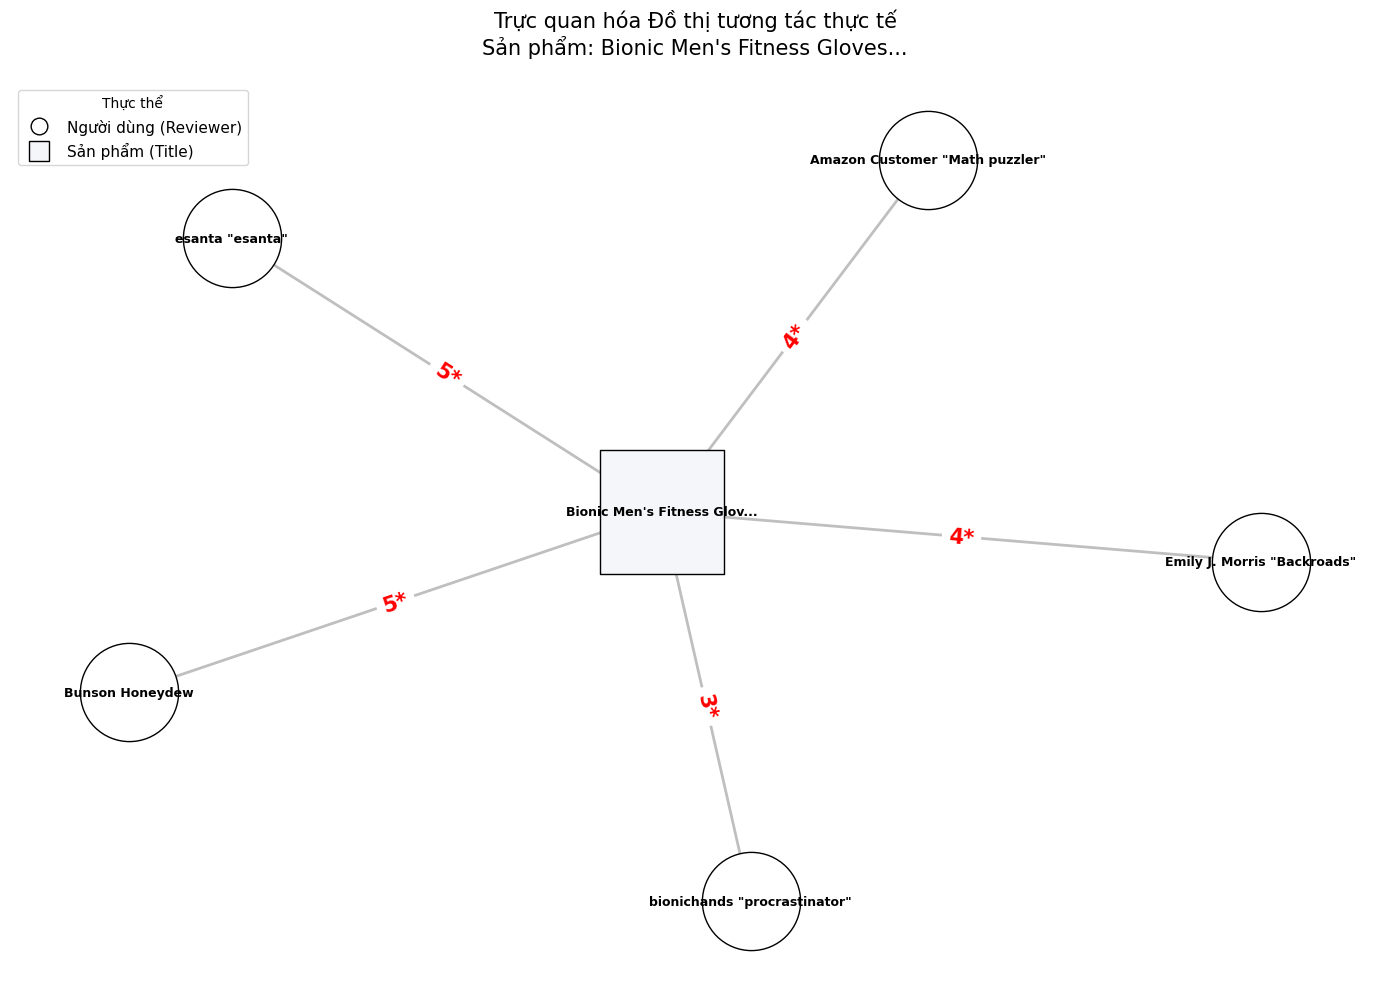

In [96]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# 1. Khởi tạo đồ thị từ DataFrame df_product_final_plot
G = nx.Graph()

# Lấy tên sản phẩm làm node trung tâm (rút gọn để không bị tràn node)
raw_title = df_product_final_plot['title'].iloc[0]
item_node_name = (raw_title[:25] + '...') if len(raw_title) > 25 else raw_title

# 2. Thêm các cạnh và node dựa trên dữ liệu thực tế
for _, row in df_product_final_plot.iterrows():
    u_name = row['reviewerName']
    r_label = f"{int(row['rating'])}*"
    
    # Tạo kết nối giữa người dùng và sản phẩm kèm nhãn rating
    G.add_edge(u_name, item_node_name, label=r_label)

# Tách danh sách node để định dạng hình dáng
user_nodes = [n for n in G.nodes if n != item_node_name]
item_node = [item_node_name]

# 3. Cấu hình vẽ đồ thị
plt.figure(figsize=(14, 10))
# Sử dụng spring_layout để các tên dài không bị đè lên nhau
pos = nx.spring_layout(G, k=1.5, seed=42) 

# --- VẼ CÁC THỰC THỂ ---
# Vẽ Người dùng: Hình tròn (o), nền trắng
nx.draw_networkx_nodes(G, pos, nodelist=user_nodes, node_shape='o', 
                       node_size=5000, node_color='white', edgecolors='black')

# Vẽ Sản phẩm: Hình vuông (s), nền xám nhạt
nx.draw_networkx_nodes(G, pos, nodelist=item_node, node_shape='s', 
                       node_size=8000, node_color='#f5f6fa', edgecolors='black')

# Vẽ nhãn Text (Tên reviewer và Tiêu đề sản phẩm)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# Vẽ đường nối (Cạnh)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.5, edge_color='gray')

# Vẽ nhãn Rating (Sao) màu đỏ nổi bật trên cạnh
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                              font_size=15, font_color='red', font_weight='bold')

# --- CHÚ THÍCH (LEGEND) ---
user_handle = mlines.Line2D([], [], color='none', marker='o', markeredgecolor='black', 
                             markerfacecolor='white', markersize=12, label='Người dùng (Reviewer)')
item_handle = mlines.Line2D([], [], color='none', marker='s', markeredgecolor='black', 
                             markerfacecolor='#f5f6fa', markersize=15, label='Sản phẩm (Title)')

plt.legend(handles=[user_handle, item_handle], loc='upper left', title="Thực thể", fontsize=11)

plt.title(f"Trực quan hóa Đồ thị tương tác thực tế\nSản phẩm: {raw_title[:50]}...", fontsize=15, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

In [112]:
import pandas as pd

# 1. Tạo tập hợp những người dùng có reviewerName không phải là số và không rỗng
# Ta dùng .str.contains('[a-zA-Z]') để đảm bảo tên có ít nhất một chữ cái
df_valid_users = df_meta_with_reviews[
    df_meta_with_reviews['reviewerName'].str.contains('[a-zA-Z]', na=False)
].copy()

# 2. Tìm người dùng hợp lệ mà cũng có tồn tại trong bảng ratings
df_user_pool = pd.merge(
    df_ratings[['userID', 'itemID', 'rating']], 
    df_valid_users[['reviewerID', 'reviewerName']].drop_duplicates(),
    left_on='userID', right_on='reviewerID', how='inner'
)

# 3. Chọn người dùng đầu tiên từ danh sách "sạch" này
if not df_user_pool.empty:
    # Lấy người dùng có nhiều đánh giá một chút để đồ thị đẹp (tùy chọn)
    selected_user = df_user_pool.groupby('userID').size().sort_values(ascending=False).index[0]
    
    target_user_id = selected_user
    target_user_name = df_user_pool[df_user_pool['userID'] == target_user_id]['reviewerName'].iloc[0]
    
    # 4. Lọc đánh giá và lấy thông tin sản phẩm
    df_user_ratings = df_ratings[df_ratings['userID'] == target_user_id].copy()
    item_ids = df_user_ratings['itemID'].unique()
    df_items_info = df_meta_with_image[df_meta_with_image['asin'].isin(item_ids)][['asin', 'title']]

    # 5. Ghép bảng cuối cùng
    df_user_final_plot = pd.merge(df_user_ratings, df_items_info, left_on='itemID', right_on='asin', how='inner')
    df_user_final_plot['reviewerName'] = target_user_name
    
    # Lấy 5-6 sản phẩm để vẽ
    df_user_final_plot = df_user_final_plot.head(6)
    
    print(f"Đã lọc thành công người dùng: {target_user_name} ({target_user_id})")
    display(df_user_final_plot[['reviewerName', 'title', 'rating']])
else:
    print("Không tìm thấy người dùng nào có tên bằng chữ trong dữ liệu!")

Đã lọc thành công người dùng: C. Hill "CFH" (A3OXHLG6DIBRW8)


,reviewerName,title,rating
0,"C. Hill ""CFH""",Victorinox Swiss Army Classic SD Pocket Knife,5.0
1,"C. Hill ""CFH""",Airzooka - Black,4.0
2,"C. Hill ""CFH""",SOG Specialty Knives &amp; Tools FSA98-CP Flash II Knife...,5.0
3,"C. Hill ""CFH""",3M Peltor Tactical 6S Active Volume Hearing Protector,4.0
4,"C. Hill ""CFH""",AirZooka Air Gun - Blue,4.0
5,"C. Hill ""CFH""",Tasco World Class 3-9x40 Riflescope w/30/30 Reticle (Matte),4.0


In [113]:
# Kiểm tra xem tên thật sự trong bảng gốc là gì
check_user = df_meta_with_reviews[df_meta_with_reviews['reviewerID'] == 'A3OXHLG6DIBRW8']
print(check_user[['reviewerID', 'reviewerName']])

            reviewerID   reviewerName
579     A3OXHLG6DIBRW8  C. Hill "CFH"
1608    A3OXHLG6DIBRW8  C. Hill "CFH"
1784    A3OXHLG6DIBRW8  C. Hill "CFH"
1908    A3OXHLG6DIBRW8  C. Hill "CFH"
1976    A3OXHLG6DIBRW8  C. Hill "CFH"
...                ...            ...
294840  A3OXHLG6DIBRW8  C. Hill "CFH"
295549  A3OXHLG6DIBRW8  C. Hill "CFH"
295814  A3OXHLG6DIBRW8  C. Hill "CFH"
295872  A3OXHLG6DIBRW8  C. Hill "CFH"
295903  A3OXHLG6DIBRW8  C. Hill "CFH"

[296 rows x 2 columns]


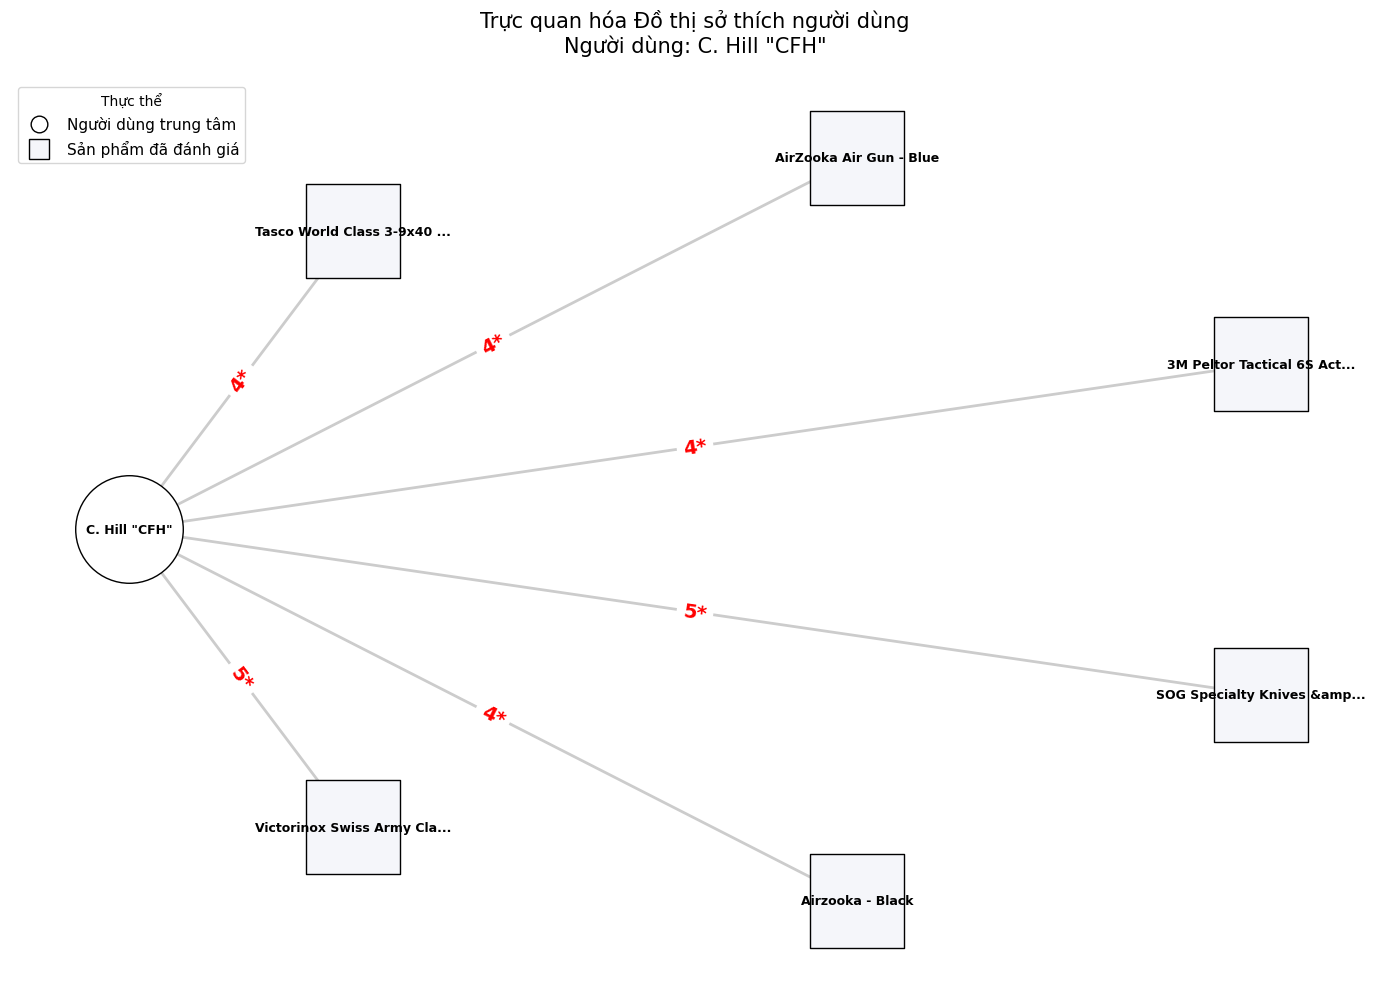

In [114]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# 1. Khởi tạo đồ thị
G = nx.Graph()

# Lấy tên người dùng làm node trung tâm
user_center_name = str(df_user_final_plot['reviewerName'].iloc[0])

# 2. Thêm các cạnh nối từ người dùng đến các sản phẩm họ đã đánh giá
for _, row in df_user_final_plot.iterrows():
    # Rút gọn tiêu đề sản phẩm cho gọn node
    raw_title = str(row['title'])
    item_label = (raw_title[:25] + '...') if len(raw_title) > 25 else raw_title
    rating_val = f"{int(row['rating'])}*"
    
    G.add_edge(user_center_name, item_label, label=rating_val)

# Tách danh sách node để định dạng
user_node = [user_center_name]
item_nodes = [n for n in G.nodes if n != user_center_name]

# 3. Vẽ đồ thị
plt.figure(figsize=(14, 10))
# Sử dụng shell_layout để tạo hình sao với User ở giữa
pos = nx.shell_layout(G) 

# Vẽ Người dùng trung tâm: Hình tròn (o), nền trắng
nx.draw_networkx_nodes(G, pos, nodelist=user_node, node_shape='o', 
                       node_size=6000, node_color='white', edgecolors='black')

# Vẽ các Sản phẩm vệ tinh: Hình vuông (s), nền xám nhạt
nx.draw_networkx_nodes(G, pos, nodelist=item_nodes, node_shape='s', 
                       node_size=4500, node_color='#f5f6fa', edgecolors='black')

# Vẽ nhãn Text (Tên người dùng và Tiêu đề sản phẩm)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# Vẽ đường nối (Cạnh)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.4, edge_color='gray')

# Vẽ nhãn Rating màu đỏ trên cạnh
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                              font_size=14, font_color='red', font_weight='bold')

# --- CHÚ THÍCH (LEGEND) ---
user_h = mlines.Line2D([], [], color='none', marker='o', markeredgecolor='black', 
                        markerfacecolor='white', markersize=12, label='Người dùng trung tâm')
item_h = mlines.Line2D([], [], color='none', marker='s', markeredgecolor='black', 
                        markerfacecolor='#f5f6fa', markersize=15, label='Sản phẩm đã đánh giá')

plt.legend(handles=[user_h, item_h], loc='upper left', title="Thực thể", fontsize=11)

plt.title(f"Trực quan hóa Đồ thị sở thích người dùng\nNgười dùng: {user_center_name}", fontsize=15, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()